# Attribution & ROMI — Tasks 6 and 8

Этот notebook визуализирует результаты attribution и ROMI.

Продажи в `sales_mart.csv` основаны на реальных данных. Исторические marketing placements, touches и costs в исходных данных отсутствуют, поэтому для демонстрации measurement pipeline используются synthetic marketing data.

Графики ниже показывают работу аналитического контура и чувствительность результатов к выбранной attribution model. Они не являются доказательством causal/incremental эффекта конкретных каналов.

## Источники данных

В анализе используются два типа данных:

- `sales_mart.csv` — реальные данные о продажах, агрегированные до уровня заказа. Заказ определяется как совокупность строк с одинаковыми `student_id` и `timestamp`.
- `mock_placements.csv` и `mock_touches.csv` — synthetic marketing data, созданные для демонстрации end-to-end attribution pipeline.

В исходных данных отсутствуют полная история рекламных размещений, marketing touches и фактические marketing costs. Поэтому synthetic data используются только для проверки механики attribution и ROMI.

Результаты по конкретным campaigns и publishers нельзя интерпретировать как фактическую историческую эффективность рекламы.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd


CURRENT_DIR = Path.cwd().resolve()

if CURRENT_DIR.name == "notebooks":
    MODULE_ROOT = CURRENT_DIR.parent
elif (CURRENT_DIR / "src").exists():
    MODULE_ROOT = CURRENT_DIR
elif (CURRENT_DIR / "analytics" / "attribution_romi").exists():
    MODULE_ROOT = CURRENT_DIR / "analytics" / "attribution_romi"
else:
    raise RuntimeError("Не удалось определить корень attribution_romi")

if str(MODULE_ROOT) not in sys.path:
    sys.path.insert(0, str(MODULE_ROOT))

OUTPUT_DIR = MODULE_ROOT / "outputs"

required_files = [
    OUTPUT_DIR / "attribution_coverage.csv",
    OUTPUT_DIR / "attribution_results.csv",
    OUTPUT_DIR / "romi_by_campaign.csv",
    OUTPUT_DIR / "romi_by_placement.csv",
    OUTPUT_DIR / "romi_by_publisher.csv",
    OUTPUT_DIR / "romi_sensitivity.csv",
]

if not all(path.exists() and path.stat().st_size > 0 for path in required_files):
    from src.pipeline import run_pipeline
    run_pipeline(regenerate_mock=True)

coverage = pd.read_csv(OUTPUT_DIR / "attribution_coverage.csv")
attribution = pd.read_csv(OUTPUT_DIR / "attribution_results.csv")
romi_campaign = pd.read_csv(OUTPUT_DIR / "romi_by_campaign.csv")
romi_placement = pd.read_csv(OUTPUT_DIR / "romi_by_placement.csv")
romi_publisher = pd.read_csv(OUTPUT_DIR / "romi_by_publisher.csv")
sensitivity = pd.read_csv(OUTPUT_DIR / "romi_sensitivity.csv")

MODEL_ORDER = [
    "first_touch",
    "last_touch",
    "linear",
    "time_decay",
    "position_based",
]

coverage["model"] = pd.Categorical(
    coverage["model"],
    categories=MODEL_ORDER,
    ordered=True,
)
coverage = coverage.sort_values("model")

romi_campaign["model"] = pd.Categorical(
    romi_campaign["model"],
    categories=MODEL_ORDER,
    ordered=True,
)
romi_campaign = romi_campaign.sort_values(["campaign_id", "model"])

print(f"Attribution rows: {len(attribution):,}")
print(f"Campaign ROMI rows: {len(romi_campaign):,}")

Attribution rows: 3,803
Campaign ROMI rows: 15


## 1. Attribution coverage

Показывает, какая доля заказов и выручки получила хотя бы одно допустимое marketing touch внутри attribution window.

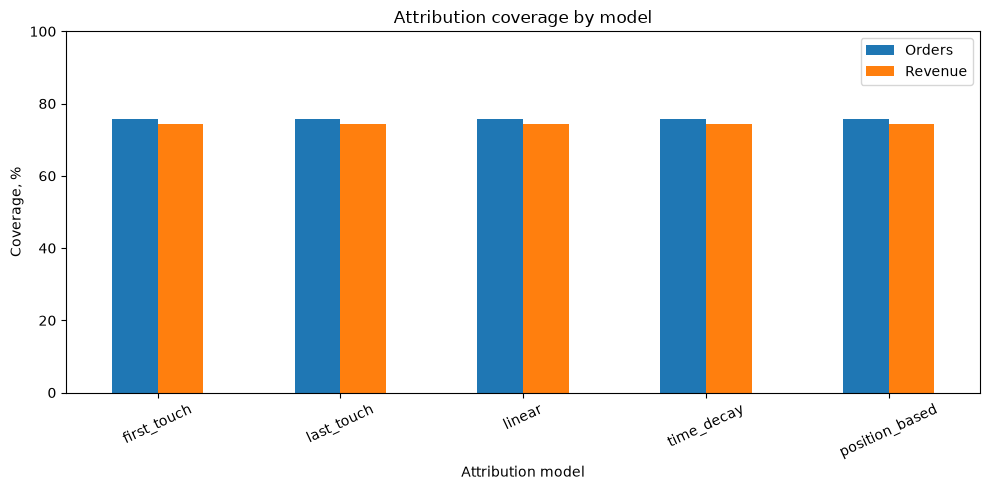

In [2]:
coverage_plot = coverage.copy()
coverage_plot["order_coverage_pct"] = coverage_plot["order_coverage"] * 100
coverage_plot["revenue_coverage_pct"] = coverage_plot["revenue_coverage"] * 100

ax = coverage_plot.plot(
    x="model",
    y=["order_coverage_pct", "revenue_coverage_pct"],
    kind="bar",
    figsize=(10, 5),
)

ax.set_title("Attribution coverage by model")
ax.set_xlabel("Attribution model")
ax.set_ylabel("Coverage, %")
ax.legend(["Orders", "Revenue"])
ax.tick_params(axis="x", rotation=25)
ax.set_ylim(0, 100)
plt.tight_layout()
plt.show()


Во всех моделях coverage одинаковый, потому что меняется способ распределения веса между уже найденными touches, а не правило отбора touch внутри attribution window.

### Repeat purchases

Repeat purchases учитываются как отдельные заказы.

Для каждого заказа attribution window рассчитывается отдельно относительно его `timestamp`. Поэтому один и тот же более ранний touch может участвовать в attribution нескольких repeat purchases, если он находится внутри соответствующего attribution window.

Это осознанное допущение MVP. Из-за короткой истории продаж наблюдаемая доля repeat purchases является censored и не отражает полный customer lifetime.

### Organic / unattributed orders

Не для каждого заказа существует eligible marketing touch.

Такие заказы не распределяются искусственно между известными placements и остаются в organic / unattributed bucket.

Отсутствие attribution не означает отсутствие маркетингового влияния. Оно означает, что в доступных данных нет наблюдаемого touch, который можно корректно связать с заказом внутри attribution window.

В synthetic marketing data часть заказов намеренно оставлена без marketing touches, чтобы pipeline корректно обрабатывал такой сценарий.

### Attribution models in MVP

В аналитическом pipeline сравниваются пять attribution models:

- `first_touch`
- `last_touch`
- `linear`
- `time_decay`
- `position_based`

`time_decay` и `position_based` используются для сравнения моделей и sensitivity analysis.

Это позволяет сравнить несколько подходов к атрибуции, не усложняя основной MVP, где используется Last Touch.

## 2. Attributed revenue by campaign and model

Сравнение показывает, насколько вывод о вкладе конкретной campaign зависит от выбранной attribution model.

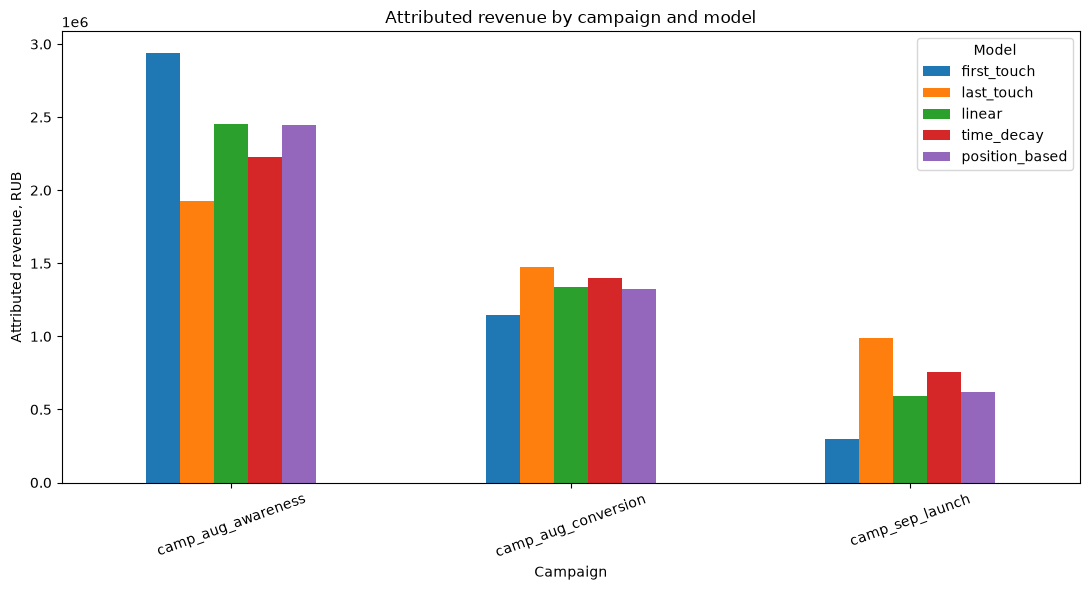

In [3]:
campaign_revenue = (
    romi_campaign
    .pivot(
        index="campaign_id",
        columns="model",
        values="attributed_revenue",
    )
    .reindex(columns=MODEL_ORDER)
)

ax = campaign_revenue.plot(
    kind="bar",
    figsize=(11, 6),
)

ax.set_title("Attributed revenue by campaign and model")
ax.set_xlabel("Campaign")
ax.set_ylabel("Attributed revenue, RUB")
ax.tick_params(axis="x", rotation=20)
ax.legend(title="Model")
plt.tight_layout()
plt.show()


## ROMI_attr vs ROMI_inc

В рамках MVP разделяются две разные метрики.

`ROMI_attr` показывает эффективность marketing spend на основе attribution:

`ROMI_attr = (Attributed Revenue - Marketing Cost) / Marketing Cost`

Эта метрика зависит от выбранной attribution model и не является causal estimate.

`ROMI_inc` должен использовать incremental revenue — дополнительную revenue, которая возникла именно благодаря marketing exposure:

`ROMI_inc = (Incremental Revenue - Marketing Cost) / Marketing Cost`

На имеющихся historical data `ROMI_inc` достоверно определить нельзя, поскольку отсутствует control group или другой источник counterfactual.

Поэтому в текущем MVP рассчитывается `ROMI_attr`, а `ROMI_inc` рассматривается как следующий этап после проведения causal experiment.

## 3. ROMI_attr by campaign and model

`ROMI_attr = (Attributed Revenue - Marketing Cost) / Marketing Cost`

Значения основаны на synthetic marketing costs, поэтому график демонстрирует механику метрики, а не реальную историческую эффективность кампаний.

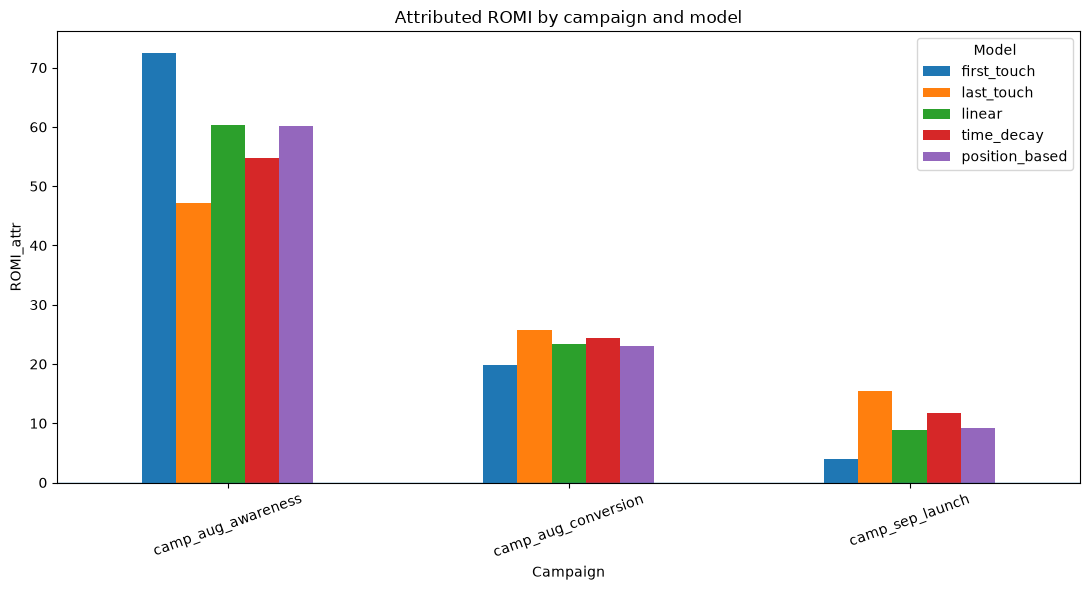

In [4]:
campaign_romi_attr = (
    romi_campaign
    .pivot(
        index="campaign_id",
        columns="model",
        values="romi_attr",
    )
    .reindex(columns=MODEL_ORDER)
)

ax = campaign_romi_attr.plot(
    kind="bar",
    figsize=(11, 6),
)

ax.axhline(0, linewidth=1)
ax.set_title("Attributed ROMI by campaign and model")
ax.set_xlabel("Campaign")
ax.set_ylabel("ROMI_attr")
ax.tick_params(axis="x", rotation=20)
ax.legend(title="Model")
plt.tight_layout()
plt.show()


## 4. Contribution-based ROMI

В исходных данных contribution margin отсутствует. Ниже используется сценарий `contribution_margin_rate = 0.6`, поэтому результат нужно интерпретировать как sensitivity analysis, а не как наблюдаемую фактическую маржинальность.

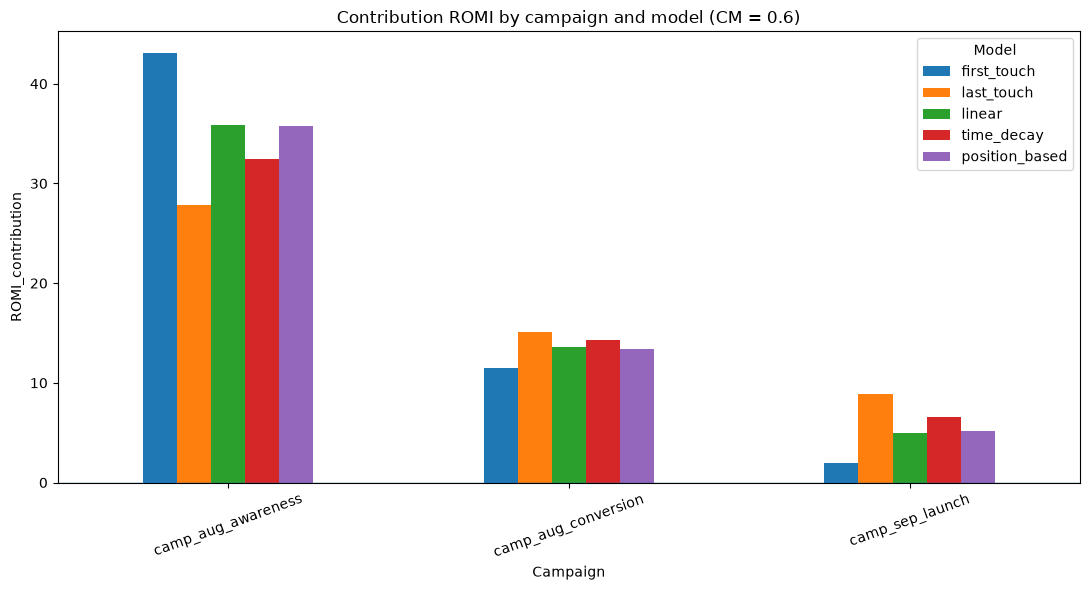

In [5]:
campaign_romi_contribution = (
    romi_campaign
    .pivot(
        index="campaign_id",
        columns="model",
        values="romi_contribution",
    )
    .reindex(columns=MODEL_ORDER)
)

ax = campaign_romi_contribution.plot(
    kind="bar",
    figsize=(11, 6),
)

ax.axhline(0, linewidth=1)
ax.set_title("Contribution ROMI by campaign and model (CM = 0.6)")
ax.set_xlabel("Campaign")
ax.set_ylabel("ROMI_contribution")
ax.tick_params(axis="x", rotation=20)
ax.legend(title="Model")
plt.tight_layout()
plt.show()


## 5. ROMI by publisher

Этот график показывает, как attribution распределяет выручку и ROMI между synthetic Telegram publishers. Для читаемости используется linear attribution.

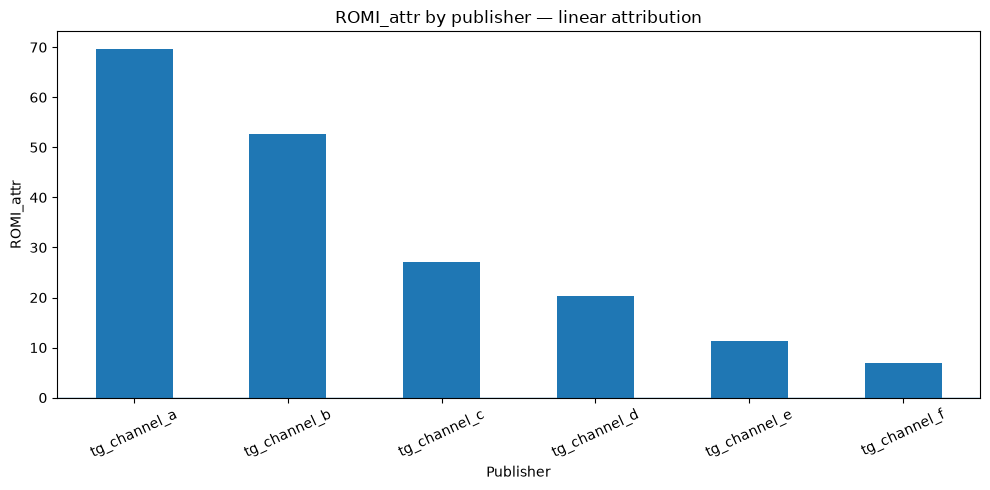

In [6]:
publisher_linear = (
    romi_publisher[
        romi_publisher["model"] == "linear"
    ]
    .sort_values("romi_attr", ascending=False)
)

ax = publisher_linear.plot(
    x="publisher",
    y="romi_attr",
    kind="bar",
    figsize=(10, 5),
    legend=False,
)

ax.axhline(0, linewidth=1)
ax.set_title("ROMI_attr by publisher — linear attribution")
ax.set_xlabel("Publisher")
ax.set_ylabel("ROMI_attr")
ax.tick_params(axis="x", rotation=25)
plt.tight_layout()
plt.show()


## 6. Attribution-window sensitivity

Проверяем, насколько `ROMI_attr` меняется при attribution window 7, 14, 30, 60 и 90 дней.

Для каждой campaign сравниваем пять attribution models. В sensitivity-grid присутствуют несколько значений `cm_rate`; для `ROMI_attr` contribution margin не влияет на результат, поэтому для устранения дублирующихся строк используется один срез `cm_rate = 0.6`.

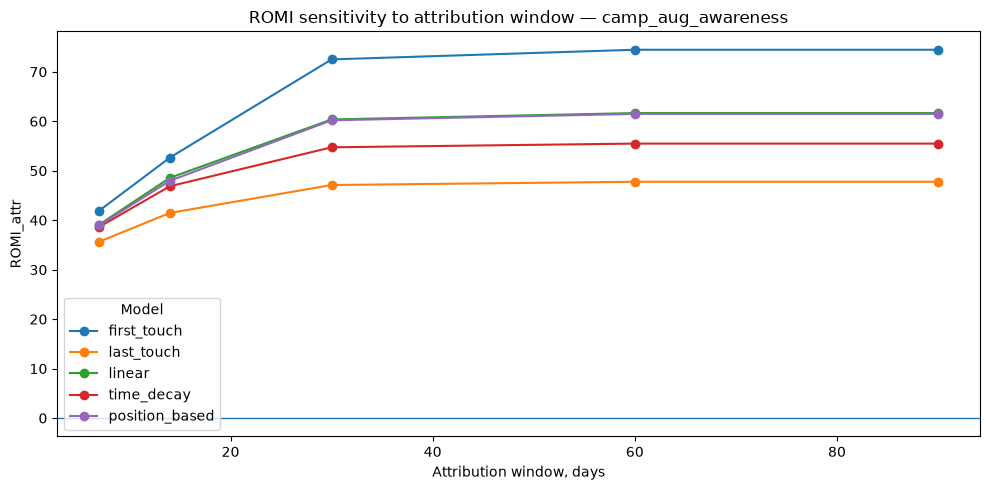

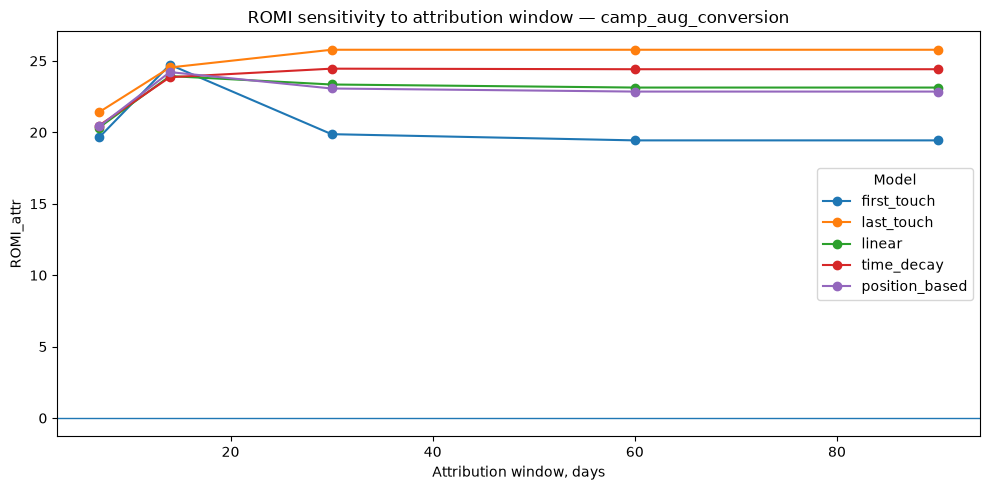

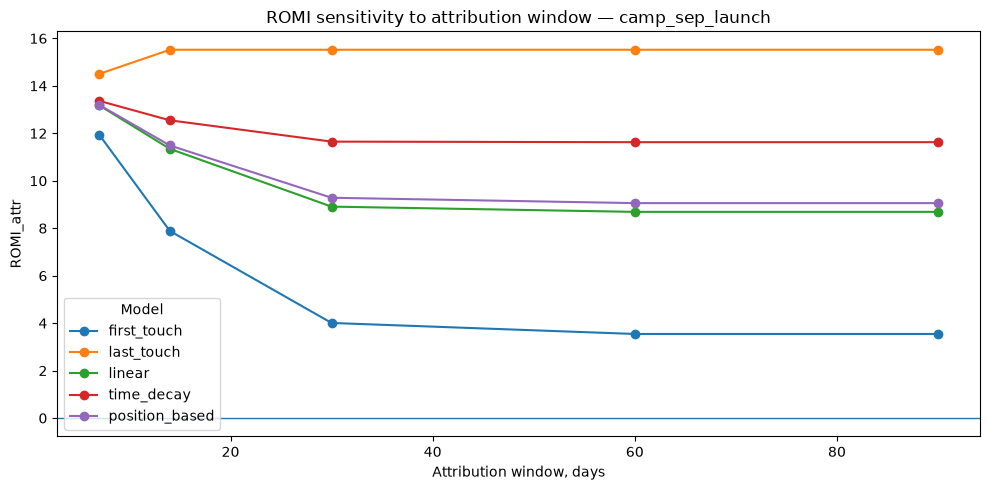

In [7]:
sensitivity_cm = sensitivity[
    sensitivity["cm_rate"].round(6) == 0.6
].copy()

sensitivity_cm["model"] = pd.Categorical(
    sensitivity_cm["model"],
    categories=MODEL_ORDER,
    ordered=True,
)

for campaign_id in sorted(
    sensitivity_cm["campaign_id"].unique()
):
    campaign_data = sensitivity_cm[
        sensitivity_cm["campaign_id"] == campaign_id
    ]

    pivot = (
        campaign_data
        .pivot(
            index="attribution_window_days",
            columns="model",
            values="romi_attr",
        )
        .reindex(columns=MODEL_ORDER)
        .sort_index()
    )

    ax = pivot.plot(
        kind="line",
        marker="o",
        figsize=(10, 5),
    )

    ax.set_title(
        f"ROMI sensitivity to attribution window — {campaign_id}"
    )
    ax.set_xlabel("Attribution window, days")
    ax.set_ylabel("ROMI_attr")
    ax.axhline(0, linewidth=1)
    ax.legend(title="Model")
    plt.tight_layout()
    plt.show()


## 7. Sensitivity по contribution margin

`Contribution margin` отсутствует в исходных данных и является допущением. Поэтому отдельно проверяем, как меняется `ROMI_contribution` при `contribution margin` 0.4, 0.5, 0.6 и 0.7.

Чтобы не смешивать влияние нескольких параметров, фиксируем `linear` attribution model и attribution window 30 дней. Линии на графике соответствуют отдельным campaigns.

Этот график показывает чувствительность результата к допущению о `contribution margin`; он не превращает synthetic marketing costs в фактические исторические данные.

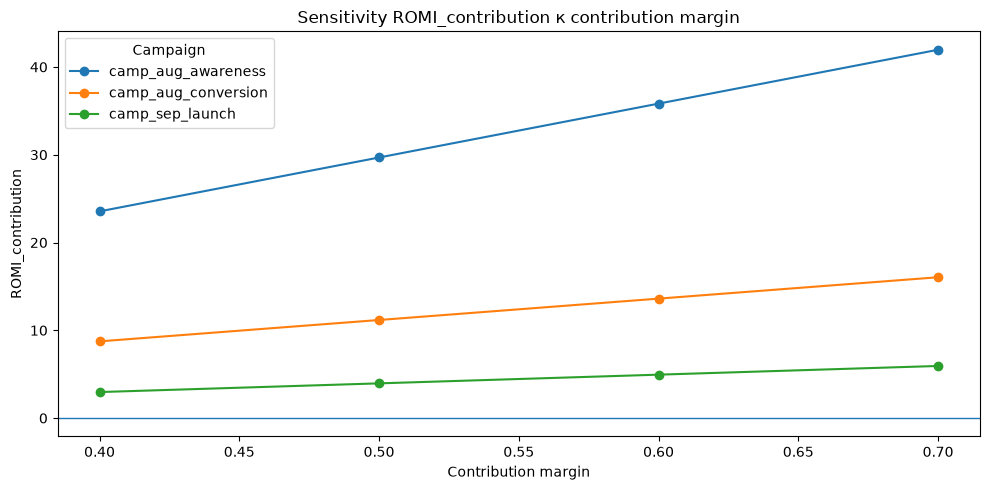

In [8]:
cm_sensitivity = sensitivity[
    (sensitivity["model"] == "linear")
    & (sensitivity["attribution_window_days"] == 30)
].copy()

cm_sensitivity = (
    cm_sensitivity[
        [
            "campaign_id",
            "cm_rate",
            "romi_contribution",
        ]
    ]
    .drop_duplicates()
)

pivot = (
    cm_sensitivity
    .pivot(
        index="cm_rate",
        columns="campaign_id",
        values="romi_contribution",
    )
    .sort_index()
)

ax = pivot.plot(
    kind="line",
    marker="o",
    figsize=(10, 5),
)

ax.axhline(0, linewidth=1)
ax.set_title(
    "Sensitivity ROMI_contribution к contribution margin"
)
ax.set_xlabel("Contribution margin")
ax.set_ylabel("ROMI_contribution")
ax.legend(title="Campaign")
plt.tight_layout()
plt.show()


## Interpretation

- Attribution model существенно влияет на то, как revenue распределяется между campaigns и publishers.
- Coverage определяется наличием eligible touches, а не weighting model.
- Значения ROMI в этом notebook рассчитаны на основе synthetic placements, touches и costs, поэтому их нельзя интерпретировать как фактическую historical campaign performance.
- Contribution-based ROMI дополнительно зависит от принятого contribution margin.
- Attribution не равна incrementality. `ROMI_inc` невозможно определить на основе доступных historical data.
- Для causal budget allocation следующим шагом необходим эксперимент: A/B test, randomized holdout или другой experimental design с control group.


## Experimental design

Attribution отвечает на вопрос, как распределить наблюдаемую revenue между marketing touches, но не отвечает на вопрос, какая часть revenue была действительно создана маркетингом.

Для оценки incrementality следующим этапом предлагается randomized holdout experiment.

Пользователи, подходящие под выбранную campaign, случайным образом разделяются на:

- treatment group — получает marketing exposure;
- control group — не получает это воздействие.

Основные метрики — разница в conversion rate и revenue per eligible user между treatment group и control group.

Incremental revenue оценивается как дополнительная revenue в treatment group относительно counterfactual, представленного control group. После этого можно перейти от `ROMI_attr` к `ROMI_inc`.

Если индивидуальная randomization невозможна, альтернативами могут быть geo holdout, randomized promo или Difference-in-Differences при наличии подходящей структуры данных.